Wizualizacja 
https://www.spe.org/web/csp/datasets/set01.htm


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [ ]:
raw_data = open(r'C:\PINN_mgr\perm_case1.dat', 'r')

In [23]:
data_easting = []
data_northing = []

In [24]:
for line in raw_data.readlines():
    line = line.strip()
    if line:
        line = line.replace('(', '').replace(')', '').replace(',', ' ')
        # print(line)
    for line in line.readlines():
        data_easting = []
        data_northing = []

        x, y = line.split()
        data_easting.append(float(x))
        data_northing.append(float(y))

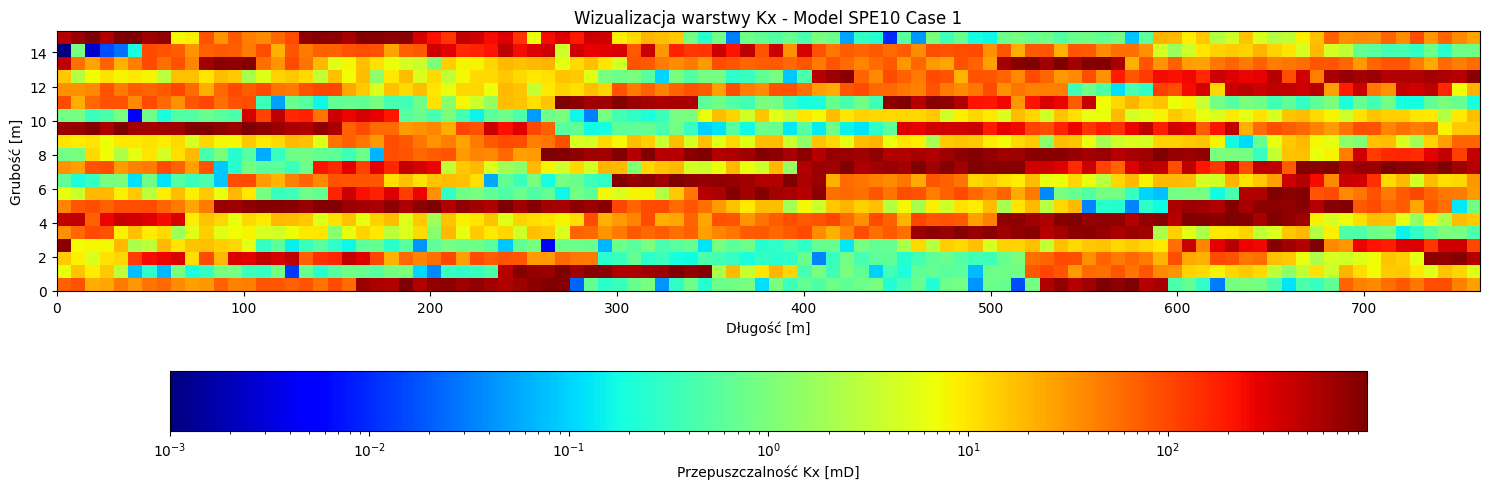

In [ ]:
NX, NZ = 100, 20
LENGTH_X = 762.0 
LENGTH_Z = 15.24 

try:
    raw_data = np.loadtxt(r'C:\PINN_mgr\perm_case1.dat').flatten()
    
    # NX * NYZ = 100 * 20 = 2000
    kx_data = raw_data[0:2000]
    
    if len(kx_data) != 2000:
        raise ValueError(f"wycięto {len(kx_data)} zamiast 2000")

    kq_matrix = kx_data.reshape((NZ, NX))
    
except Exception as e:
    print(f"Błąd {e}")
    kq_matrix = np.random.uniform(1, 100, (NZ, NX))

plt.figure(figsize=(15, 5))

img = plt.imshow(kq_matrix, 
                 cmap='jet', 
                 norm=LogNorm(), 
                 extent=[0, LENGTH_X, 0, LENGTH_Z], 
                 aspect='auto',
                 origin='lower')

plt.colorbar(img, orientation='horizontal', pad=0.2, label='Przepuszczalność Kx [mD]')
plt.title('Wizualizacja warstwy Kx - Model SPE10 Case 1')
plt.xlabel('Długość [m]')
plt.ylabel('Grubość [m]')

plt.tight_layout()
plt.show()

Kolor czerwony to wysoka przepuszczalność - gaz/olej będą się szybciej przemieszczać, zaś kolor niebieski to niska przepuszczalność, napotykana jest jakaś ściana, skała.

Wymiary całkowite: 762 metry długości, 7,62 metra szerokości oraz 15,24 metra grubości.

Fine scale grid: 100 x 1 x 20 bloków o jednakowym rozmiarze.

Rozmiary pojedynczego bloku: $\Delta$ x = 7, 62 m (762 m / 100), $\Delta$ y = 7, 62 m (stała, ponieważ zakładamy, że wszystkie parametry są identyczne na całej szerokości), $\Delta$ z = 0, 762 m ( 15, 24 m / 20)

Warunki początkowe: 

- Góra modelu znajduje się na głębokości 0,0 m z ciśnieniem początkowym wynoszącym 100 psia
- Porowatość = 0,2

Właściwości płynów:

- Lepkość: ropa (μo​) = 1 cp, gaz (μg​) = 0,01 cp (stała podczas symulacji).
- Gęstość: ropa (ρo​) = 700 kg/m³, gaz (ρg​) = 1,0 kg/m³.

Właściwości skały:

- Rozkład przepuszczalności (K) jest polem generowanym geostatystycznie (skorelowanym).

Eksploatacja (Studnie):

- Zatłaczanie: Gaz jest wtłaczany przez zatłaczacz zlokalizowany po lewej stronie modelu.

- Produkcja: Ropa (dead oil) jest wydobywana przez studnię po prawej stronie modelu.

- Obie studnie mają średnicę wewnętrzną 1,0 ft i są udostępnione pionowo przez całą miąższość modelu.

- Wskaźnik zatłaczania: Ustawiony tak, aby uzyskać prędkość frontu na poziomie 0,3 m/d (ok. 6,97 m³ na dobę).

Limit produkcji: Studnia wydobywcza ma ustawione stałe graniczne ciśnienie denne (BHP) wynoszące 95 psia. Głębokość odniesienia dla ciśnienia dennego to 0,0 m (góra modelu).

Jednostki:

psia (pounds per square inch absolute): 1 psi ≈ 6894,76 Pa (0,069 bara)

cp (centipoise): 1 cp=0,001 Pa⋅s (1 mPa⋅s) -> woda w temperaturze pokojowej ma lepkość około 1 cp

ft (foot / stopa): 1 ft=0,3048 m (około 30,5 cm)